In [1]:
# Check GPU availability
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found - check Runtime > Change runtime type > GPU")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Install required libraries
!pip install monai nibabel scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 56.8 MB/s eta 0:00:00


In [4]:
import subprocess
subprocess.run(["pip", "install", "monai", "nibabel", "scikit-image", "-q"])

CompletedProcess(args=['pip', 'install', 'monai', 'nibabel', 'scikit-image', '-q'], returncode=0)

In [5]:
import os

dataset_path = '/content/drive/MyDrive/Medical-AI/Task09_Spleen'

if os.path.exists(dataset_path):
    print("Dataset found.")
    for folder in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            count = len(os.listdir(folder_path))
            print(f"{folder}: {count} files")
else:
    print("Dataset not found yet - still uploading")


Dataset found.
imagesTs: 40 files
labelsTr: 82 files
imagesTr: 82 files


In [6]:
import os
import glob

dataset_path = '/content/drive/MyDrive/Medical-AI/Task09_Spleen'

# Get all training image and label pairs
images = sorted(glob.glob(os.path.join(dataset_path, 'imagesTr', '*.nii.gz')))
labels = sorted(glob.glob(os.path.join(dataset_path, 'labelsTr', '*.nii.gz')))

print(f"Training images found: {len(images)}")
print(f"Training labels found: {len(labels)}")
print(f"\nFirst image: {os.path.basename(images[0])}")
print(f"First label: {os.path.basename(labels[0])}")

# Create data dictionaries - MONAI expects list of dicts
data_dicts = [{"image": img, "label": lbl}
              for img, lbl in zip(images, labels)]

# Split 80/20 train/validation
split = int(len(data_dicts) * 0.8)
train_files = data_dicts[:split]
val_files = data_dicts[split:]

print(f"\nTraining cases: {len(train_files)}")
print(f"Validation cases: {len(val_files)}")

Training images found: 41
Training labels found: 41

First image: spleen_10.nii.gz
First label: spleen_10.nii.gz

Training cases: 32
Validation cases: 9


In [7]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandRotate90d,
    ToTensord,
    EnsureTyped,
)

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=-57, a_max=164,
        b_min=0.0, b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 32),
        pos=1, neg=1,
        num_samples=2,
        image_key="image",
        image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=-57, a_max=164,
        b_min=0.0, b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    EnsureTyped(keys=["image", "label"]),
])

print("Transforms created successfully")
print("Training: load -> normalise -> crop foreground -> random patches -> augment")
print("Validation: load -> normalise -> crop foreground")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Transforms created successfully
Training: load -> normalise -> crop foreground -> random patches -> augment
Validation: load -> normalise -> crop foreground


In [8]:
from monai.data import Dataset, DataLoader, CacheDataset

# CacheDataset loads and caches data in memory
# Faster than loading from disk every epoch
# Use regular Dataset if you run out of RAM

train_dataset = Dataset(
    data=train_files,
    transform=train_transforms,

)

val_dataset = Dataset(
    data=val_files,
    transform=val_transforms,
)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 32
Validation batches: 9


In [9]:
from monai.networks.nets import UNet
from monai.networks.layers import Norm

# MONAI's built-in UNet - same architecture we built from scratch
# but production-grade and optimised
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print("Using MONAI built-in UNet - same architecture you built from scratch")

Model parameters: 4,808,917
Using MONAI built-in UNet - same architecture you built from scratch


In [10]:
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.utils import first
import torch.optim as optim

# DiceCELoss combines Dice loss and Cross Entropy
# Better than Dice alone for early training stability
# Cross entropy helps when predictions are far from ground truth
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

dice_metric = DiceMetric(include_background=False, reduction="mean")

print("Loss: DiceCELoss (Dice + Cross Entropy combined)")
print("Optimizer: Adam, lr=1e-4")
print("Metric: Dice score excluding background")
print("\nReady to train.")


Loss: DiceCELoss (Dice + Cross Entropy combined)
Optimizer: Adam, lr=1e-4
Metric: Dice score excluding background

Ready to train.


In [11]:
from monai.inferers import sliding_window_inference

max_epochs = 50
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

print(f"Starting training for {max_epochs} epochs...")
print(f"Validating every {val_interval} epochs\n")

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0

    for batch_data in train_loader:
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    epoch_loss_values.append(epoch_loss)
    print(f"Epoch {epoch+1}/{max_epochs} | Loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs = val_data["image"].to(device)
                val_labels = val_data["label"].to(device)

                val_outputs = sliding_window_inference(
                    val_inputs, (96,96,32), 4, model
                )

                val_outputs = torch.argmax(val_outputs, dim=1, keepdim=True)
                val_labels_onehot = (val_labels == 1).float()
                val_outputs_onehot = (val_outputs == 1).float()

                dice_metric(
                    y_pred=val_outputs_onehot,
                    y=val_labels_onehot
                )

            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            metric_values.append(metric)

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(
                    model.state_dict(),
                    '/content/drive/MyDrive/Medical-AI/best_spleen_model.pth'
                )
                print(f"  New best Dice: {best_metric:.4f} — model saved")

print(f"\nTraining complete.")
print(f"Best Dice: {best_metric:.4f} at epoch {best_metric_epoch}")

Starting training for 50 epochs...
Validating every 2 epochs

Epoch 1/50 | Loss: 1.2986
Epoch 2/50 | Loss: 1.1540


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out

  New best Dice: 0.0801 — model saved
Epoch 3/50 | Loss: 1.0924
Epoch 4/50 | Loss: 1.0666
  New best Dice: 0.0929 — model saved
Epoch 5/50 | Loss: 0.9843
Epoch 6/50 | Loss: 0.9265
  New best Dice: 0.1243 — model saved
Epoch 7/50 | Loss: 0.9263
Epoch 8/50 | Loss: 0.8740
Epoch 9/50 | Loss: 0.8281
Epoch 10/50 | Loss: 0.7986
  New best Dice: 0.1413 — model saved
Epoch 11/50 | Loss: 0.7903
Epoch 12/50 | Loss: 0.7546
  New best Dice: 0.1437 — model saved
Epoch 13/50 | Loss: 0.6957
Epoch 14/50 | Loss: 0.7108
Epoch 15/50 | Loss: 0.6763
Epoch 16/50 | Loss: 0.6461
  New best Dice: 0.1825 — model saved
Epoch 17/50 | Loss: 0.5929
Epoch 18/50 | Loss: 0.6079
Epoch 19/50 | Loss: 0.6061
Epoch 20/50 | Loss: 0.5673
  New best Dice: 0.2171 — model saved
Epoch 21/50 | Loss: 0.5934
Epoch 22/50 | Loss: 0.5706
Epoch 23/50 | Loss: 0.5537
Epoch 24/50 | Loss: 0.5478
Epoch 25/50 | Loss: 0.5205
Epoch 26/50 | Loss: 0.5367
Epoch 27/50 | Loss: 0.5353
Epoch 28/50 | Loss: 0.5003
Epoch 29/50 | Loss: 0.4708
Epoch 30/50 

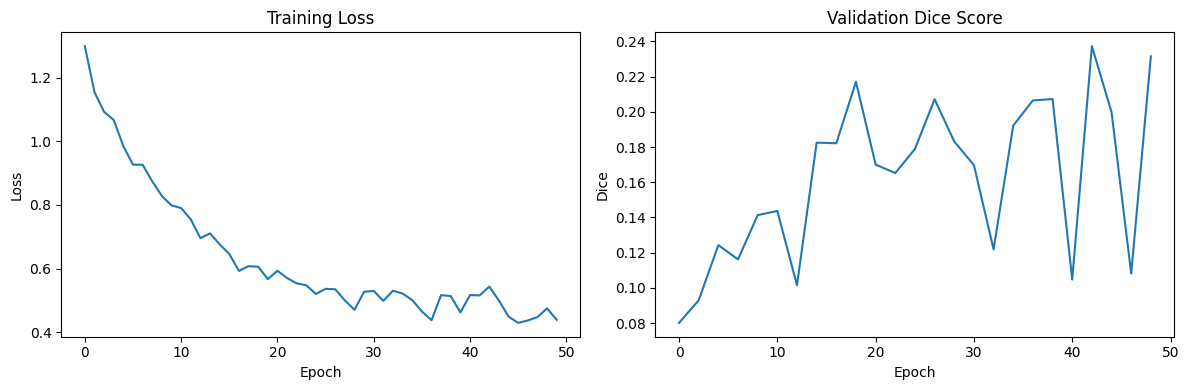

Training curves saved to Google Drive


In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epoch_loss_values)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(0, len(metric_values)*2, 2), metric_values)
ax2.set_title('Validation Dice Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Medical-AI/training_curves.png')
plt.show()
print("Training curves saved to Google Drive")